# KMeans 第七课：Iris 综合案例

前面曾用 KNN 对 Iris 做有监督分类。这次把真实标签从训练输入中拿掉，只把 4 个花朵特征交给 K-means。

完整流程：

```text
加载数据
-> 只用 X 训练
-> 标准化
-> 选择并训练 K=3
-> 查看质心和簇大小
-> 用无监督指标评估
-> 最后才用真实标签做事后对照
-> PCA 二维可视化
```

In [1]:
import os

# sklearn 1.7.x 在 Windows + MKL 的小数据集上建议限制 OpenMP 线程数
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

## 1. 加载数据

Iris 有 150 个样本、4 个特征、3 个真实类别。

本课保留 `y_true` 只用于训练完成后的评价。K-means 的 `fit` 不能接收它作为答案。

In [2]:
iris = load_iris()
X = iris.data
y_true = iris.target

print("X.shape:", X.shape)
print("y_true.shape:", y_true.shape)
print("特征:", iris.feature_names)
print("真实类别:", iris.target_names)

X.shape: (150, 4)
y_true.shape: (150,)
特征: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
真实类别: ['setosa' 'versicolor' 'virginica']


## 2. 标准化四个特征

K-means 使用四维空间中的欧氏距离。即使四列单位都是厘米，它们的离散程度也不同，标准化可以让每列处于可比较尺度。

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("标准化后均值:", X_scaled.mean(axis=0))
print("标准化后标准差:", X_scaled.std(axis=0))

标准化后均值: [-0. -0. -0. -0.]
标准化后标准差: [1. 1. 1. 1.]


## 3. 查看候选 K 的内部指标

真实标签告诉我们植物学上有 3 类，但无监督算法只看到几何结构。轮廓系数最高的 `K` 不一定等于真实类别数量，这并不矛盾。

In [4]:
candidate_k = range(2, 7)
inertias = []
silhouettes = []

for k in candidate_k:
    candidate_model = KMeans(n_clusters=k, n_init=10, random_state=22)
    candidate_labels = candidate_model.fit_predict(X_scaled)
    inertias.append(candidate_model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, candidate_labels))

for k, inertia, silhouette in zip(candidate_k, inertias, silhouettes):
    print(f"K={k}: inertia={inertia:.2f}, silhouette={silhouette:.4f}")

K=2: inertia=222.36, silhouette=0.5818
K=3: inertia=139.82, silhouette=0.4599
K=4: inertia=114.10, silhouette=0.3866
K=5: inertia=90.93, silhouette=0.3424
K=6: inertia=80.04, silhouette=0.3267


## 4. 使用 K=3 完成聚类

本案例选择 `K=3`，目的是与三个已知物种做事后对照。选择过程使用了领域信息，因此要明确说明，不能伪装成纯内部指标自动得出的结论。

In [5]:
model = KMeans(n_clusters=3, n_init=10, random_state=22)
cluster_labels = model.fit_predict(X_scaled)

print("簇大小:", np.bincount(cluster_labels))
print("inertia_:", round(model.inertia_, 3))
print("silhouette:", round(silhouette_score(X_scaled, cluster_labels), 4))

簇大小: [50 47 53]
inertia_: 139.82
silhouette: 0.4599


## 5. 解释质心

质心当前位于标准化空间。逆变换后可以重新用厘米解释每个簇的平均花朵特征。

In [6]:
centers_cm = scaler.inverse_transform(model.cluster_centers_)
centers_table = pd.DataFrame(centers_cm, columns=iris.feature_names)
centers_table.index.name = "cluster"
centers_table

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.006000,3.428000,1.462000,0.246000
1,6.780851,3.095745,5.510638,1.972340
2,5.801887,2.673585,4.369811,1.413208


## 6. 为什么不能直接计算普通准确率？

真实标签：

```text
0=setosa, 1=versicolor, 2=virginica
```

聚类标签：

```text
0/1/2 只是任意簇编号
```

即使分组完全正确，簇编号也可能是 `2/0/1`，直接做 `cluster_labels == y_true` 会误判。

ARI 和 NMI 不依赖簇编号如何排列，更适合事后对照。

In [7]:
comparison = pd.crosstab(
    pd.Series(y_true, name="true_class"),
    pd.Series(cluster_labels, name="cluster"),
)

print("真实类别与簇的交叉表:")
print(comparison)
print("ARI:", round(adjusted_rand_score(y_true, cluster_labels), 4))
print("NMI:", round(normalized_mutual_info_score(y_true, cluster_labels), 4))

真实类别与簇的交叉表:
cluster      0   1   2
true_class            
0           50   0   0
1            0  11  39
2            0  36  14
ARI: 0.6201
NMI: 0.6595


## 7. 使用 PCA 做二维可视化

模型仍然使用全部 4 个标准化特征训练。

PCA 只负责把四维坐标压到二维，方便画图：

```text
四维标准化数据 -> PCA 二维坐标 -> 绘图
```

因此图是投影视图，不包含四维空间的全部信息。

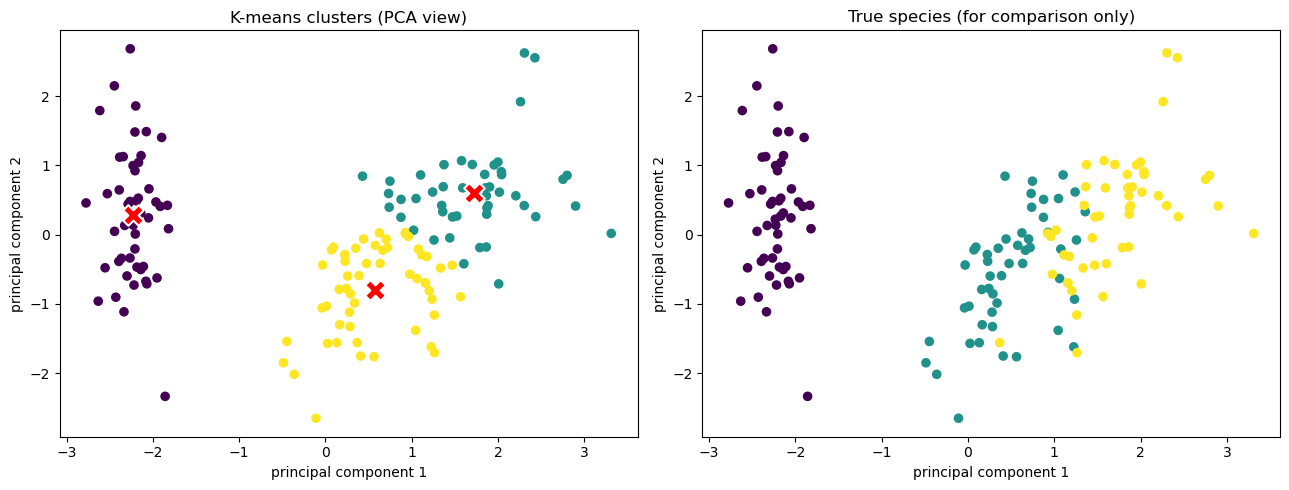

In [8]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
centers_2d = pca.transform(model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="viridis", s=35)
axes[0].scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c="red", marker="X", s=220, edgecolors="white", linewidths=1.5,
)
axes[0].set_title("K-means clusters (PCA view)")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis", s=35)
axes[1].set_title("True species (for comparison only)")

for ax in axes:
    ax.set_xlabel("principal component 1")
    ax.set_ylabel("principal component 2")

plt.tight_layout()
plt.show()

## 8. 为一朵新花分配簇

新样本必须按相同顺序提供 4 个特征，并使用已有 `scaler.transform`。

In [9]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
new_flower_scaled = scaler.transform(new_flower)
new_cluster = model.predict(new_flower_scaled)[0]

print("新花特征:", new_flower[0])
print("分配到簇:", new_cluster)
print("该簇质心（厘米）:", centers_cm[new_cluster])

新花特征: [5.1 3.5 1.4 0.2]
分配到簇: 0
该簇质心（厘米）: [5.006 3.428 1.462 0.246]


## 9. 案例结论

Iris 案例揭示了聚类与分类的本质区别：

```text
KNN 分类 -> 用真实物种标签训练，目标是预测物种
K-means  -> 不看物种标签，目标是寻找特征空间中的分组
```

Iris 中 setosa 与其他花朵分离明显，而 versicolor 和 virginica 存在重叠，所以几何分组不必与植物学类别完全一致。

## 10. 本课小结

- 训练时只向 K-means 提供 `X`；
- 标准化后再计算四维距离；
- 内部指标和真实类别数量可能给出不同视角；
- 簇编号没有固定语义；
- 有真实标签时使用 ARI、NMI 做事后评估；
- PCA 只用于展示，不应误认为模型只使用两个特征；
- 新样本必须复用同一个标准化器。